In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

In [33]:
df = pd.read_csv("data/TCL_wt1.tsv", sep = "\t", na_values= "#VALEUR!")
df = df.dropna()

df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183,-3.009460,0.036746,1.434787


In [36]:
values = df[['Description', 'Gene Symbol']]
values.head()

,Description,Gene Symbol
0,Basal-body rod modification protein FlgD OS=Es...,flgD
1,Uncharacterized protein YeaC OS=Escherichia co...,yeaC
2,Flagellar transcriptional regulator FlhD OS=Es...,flhD
4,PTS system glucitol/sorbitol-specific EIIA com...,srlB
5,Flagellar hook-associated protein 3 OS=Escheri...,flgL


In [42]:
df.iloc[:,[0, 2, 3]]

,Accession,Gene Symbol,Corrected Abundance ratio (1.53)
0,P75936,flgD,0.075817
1,P76231,yeaC,0.092810
2,P0A8S9,flhD,0.102614
4,P05706,srlB,0.108497
5,P29744,flgL,0.124183
...,...,...,...
2011,P77330,borD,1.535948
2016,P02930,tolC,1.552288
2020,P0A917,ompX,1.579739
2021,P02931,ompF,1.754902


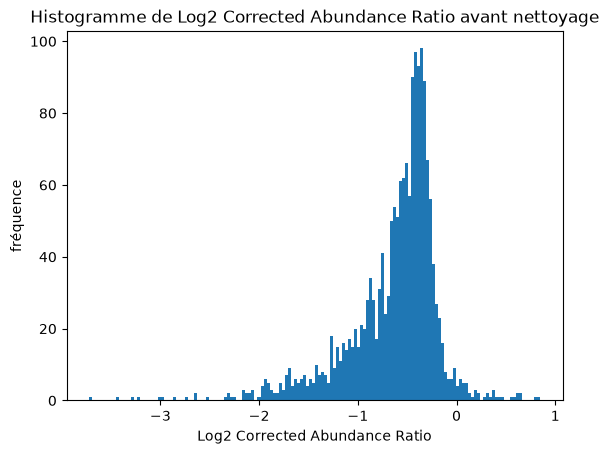

In [73]:
plt.hist(df["Log2 Corrected Abundance Ratio"], bins = (150))
plt.title("Histogramme de Log2 Corrected Abundance Ratio avant nettoyage")
plt.xlabel("Log2 Corrected Abundance Ratio")
plt.ylabel("fréquence")
plt.savefig("hist_log2_avant")

In [68]:
df_filt = df.loc[(df['Log2 Corrected Abundance Ratio'] > -2.5 ) ]

In [79]:
mu = df_filt['Log2 Corrected Abundance Ratio'].mean()
sigma = df_filt['Log2 Corrected Abundance Ratio'].std()

In [80]:
print(mu, sigma)

-0.6236474194622479 0.43193865548866134


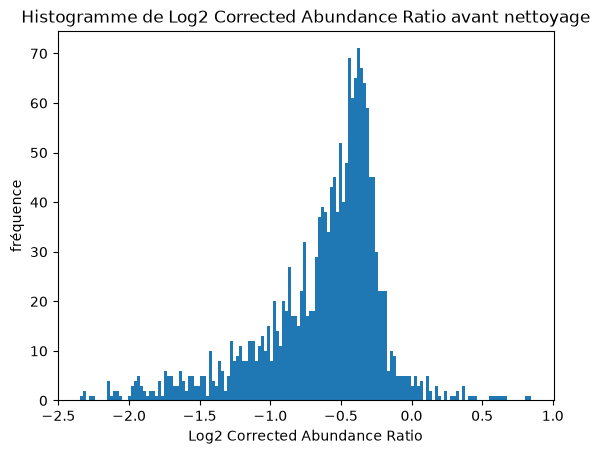

In [81]:
plt.hist(df_filt["Log2 Corrected Abundance Ratio"], bins = (150))
plt.title("Histogramme de Log2 Corrected Abundance Ratio avant nettoyage")
plt.xlabel("Log2 Corrected Abundance Ratio")
plt.ylabel("fréquence")
plt.savefig("hist_log2_après")

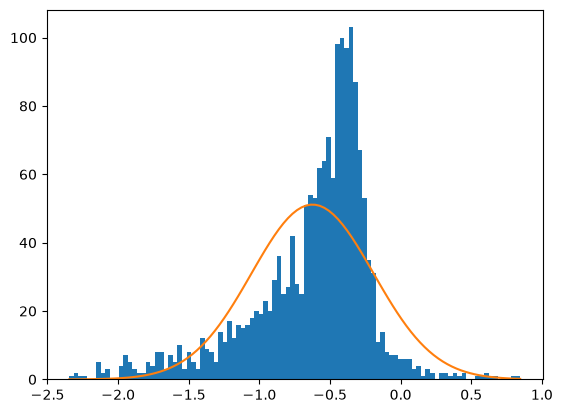

In [88]:
ig, ax = plt.subplots()
hist = ax.hist(df_filt["Log2 Corrected Abundance Ratio"], bins=100) # draw histogram
x = np.linspace(min(df_filt["Log2 Corrected Abundance Ratio"]), max(df_filt["Log2 Corrected Abundance Ratio"]), 100) # generate PDF domain points
dx = hist[1][1] - hist[1][0] # Get single value bar height
scale = len(df_filt["Log2 Corrected Abundance Ratio"])*dx # scale accordingly
ax.plot(x, norm.pdf(x, mu, sigma)*scale) # compute theoritical PDF and draw it
plt.xlabel("log2 abondance")
plt.ylabel("nombre de protéines")
plt.savefig("hist_loi_norm")